# M3 Agentic AI - Turning functions into tools

## 1. Introduction

### 1.1. Lab overview

In this ungraded lab, you will create a set of tools with `aisuite` to give to an LLM. You will see how the LLM requests tools to be used and also the LLM choosing certain tools when relevant to its task.

### 🎯 1.2 Learning outcome

Apply tool-calling design patterns to agent workflows.

To achieve this you will give LLMs controlled access to python functions via AISuite, manage parameter passing and execution flow, and validate multi-step outputs generated through tool orchestration.


In [1]:
import json
import display_functions
from dotenv import load_dotenv
_ = load_dotenv()

In [2]:
import aisuite as ai

# Create an instance of the AISuite client
client = ai.Client()


In [3]:
from datetime import datetime


def get_current_time():
    """
    Returns the current time as a string.
    """
    return datetime.now().strftime("%H:%M:%S")

In [4]:
get_current_time()

'13:26:51'

In [5]:
# Message structure
prompt = "What time is it?"
messages = [
    {
        "role": "user",
        "content": prompt,
    }
]

In [6]:
response = client.chat.completions.create(
    model="openai:gpt-5.6-luna",
    messages=messages,
    reasoning_effort="none",
    tools=[get_current_time],
    max_turns=5
)

# See the LLM response
print(response.choices[0].message.content)

It’s 1:26 PM.


In [7]:
display_functions.pretty_print_chat_completion(response)

In [8]:
tools = [{
    "type": "function",
    "function": {
        "name": "get_current_time",  # <--- Your functions name
        "description": "Returns the current time as a string.",  # <--- a description for the LLM
        "parameters": {}
    }
}]

In [9]:
response = client.chat.completions.create(
    model="openai:gpt-4o",
    messages=messages,
    tools=tools,  # <-- Your list of tools with get_current_time
    # max_turns=5 # <-- When defining tools manually, you must handle calls yourself and cannot use max_turns
)

In [10]:
print(json.dumps(response.model_dump(), indent=2, default=str))

{
  "id": "chatcmpl-EPkEIHya1K33AIBD262mbjXwx18Nq",
  "choices": [
    {
      "finish_reason": "tool_calls",
      "index": 0,
      "logprobs": null,
      "message": {
        "content": null,
        "refusal": null,
        "role": "assistant",
        "annotations": [],
        "audio": null,
        "function_call": null,
        "tool_calls": [
          {
            "id": "call_3Mgx9AC5HNWkV5UbjeC588OF",
            "function": {
              "arguments": "{}",
              "name": "get_current_time"
            },
            "type": "function"
          }
        ]
      }
    }
  ],
  "created": 1789804614,
  "model": "gpt-4o-2024-08-06",
  "object": "chat.completion",
  "metadata": null,
  "moderation": null,
  "service_tier": "default",
  "system_fingerprint": "fp_40aced2ba4",
  "usage": {
    "completion_tokens": 11,
    "prompt_tokens": 45,
    "total_tokens": 56,
    "completion_tokens_details": {
      "accepted_prediction_tokens": 0,
      "audio_tokens": 0,
     

In [11]:
response2 = None

# Create a condition in case tool_calls is in response object
if response.choices[0].message.tool_calls:
    # Pull out the specific tool metadata from the response
    tool_call = response.choices[0].message.tool_calls[0]
    args = json.loads(tool_call.function.arguments)

    # Run the get_current_time function locally if that tool name was called
    if tool_call.function.name == "get_current_time":
        tool_result = get_current_time()

    # Append the result to the messages list
    messages.append(response.choices[0].message)
    messages.append({
        "role": "tool", "tool_call_id": tool_call.id, "content": str(tool_result)
    })

    # Send the list of messages with the newly appended results back to the LLM
    response2 = client.chat.completions.create(
        model="openai:gpt-4o",
        messages=messages,
        tools=tools,
    )

    print(response2.choices[0].message.content)


The current time is 13:26:54.


In [12]:
import requests
import qrcode
from qrcode.image.styledpil import StyledPilImage


def get_weather_from_ip():
    """
    Gets the current, high, and low temperature in Fahrenheit for the user's
    location and returns it to the user.
    """
    # Get location coordinates from the IP address
    lat, lon = requests.get('https://ipinfo.io/json').json()['loc'].split(',')

    # Set parameters for the weather API call
    params = {
        "latitude": lat,
        "longitude": lon,
        "current": "temperature_2m",
        "daily": "temperature_2m_max,temperature_2m_min",
        "temperature_unit": "fahrenheit",
        "timezone": "auto"
    }

    # Get weather data
    weather_data = requests.get("https://api.open-meteo.com/v1/forecast", params=params).json()

    # Format and return the simplified string
    return (
        f"Current: {weather_data['current']['temperature_2m']}°F, "
        f"High: {weather_data['daily']['temperature_2m_max'][0]}°F, "
        f"Low: {weather_data['daily']['temperature_2m_min'][0]}°F"
    )


# Write a text file
def write_txt_file(file_path: str, content: str):
    """
    Write a string into a .txt file (overwrites if exists).
    Args:
        file_path (str): Destination path.
        content (str): Text to write.
    Returns:
        str: Path to the written file.
    """
    with open(file_path, "w", encoding="utf-8") as f:
        f.write(content)
    return file_path


# Create a QR code
def generate_qr_code(data: str, filename: str, image_path: str):
    """Generate a QR code image given data and an image path.

    Args:
        data: Text or URL to encode
        filename: Name for the output PNG file (without extension)
        image_path: Path to the image to be used in the QR code
    """
    import os

    # LLMs sometimes wrap paths in quotes/backticks; normalize them.
    image_path = str(image_path).strip().strip("`'\"")
    filename = str(filename).strip().strip("`'\"")
    if filename.lower().endswith(".png"):
        filename = filename[:-4]

    qr = qrcode.QRCode(error_correction=qrcode.constants.ERROR_CORRECT_H)
    qr.add_data(data)

    if os.path.exists(image_path):
        img = qr.make_image(image_factory=StyledPilImage, embedded_image_path=image_path)
    else:
        # Fall back to a plain QR code if the logo file is not found.
        img = qr.make_image()
    output_file = f"{filename}.png"
    img.save(output_file)

    return f"QR code saved as {output_file} containing: {data[:50]}..."

In [13]:
prompt = "Can you get the weather for my location?"

response = client.chat.completions.create(
    model="openai:o4-mini",
    messages=[{"role": "user", "content": (
        prompt
    )}],
    tools=[
        get_current_time,
        get_weather_from_ip,
        write_txt_file,
        generate_qr_code
    ],
    max_turns=5
)

display_functions.pretty_print_chat_completion(response)

In [14]:
prompt = "Can you make a txt note for me called reminders.txt that reminds me to call Daniel tomorrow at 7PM?"

response = client.chat.completions.create(
    model="openai:o4-mini",
    messages=[{"role": "user", "content": (
        prompt
    )}],
    tools=[
        get_current_time,
        get_weather_from_ip,
        write_txt_file,
        generate_qr_code
    ],
    max_turns=5
)

display_functions.pretty_print_chat_completion(response)

In [16]:
with open('reminders.txt', 'r') as file:
    contents = file.read()
    print(contents)

Reminder: Call Daniel tomorrow at 7 PM.


In [17]:
prompt = "Can you make a QR code for me using my company's logo that goes to www.deeplearning.ai? The logo is located at `dl_logo.jpg`. You can call it dl_qr_code."

response = client.chat.completions.create(
    model="openai:o4-mini",
    messages=[{"role": "user", "content": (
        prompt
    )}],
    tools=[
        get_current_time,
        get_weather_from_ip,
        write_txt_file,
        generate_qr_code
    ],
    max_turns=5
)

display_functions.pretty_print_chat_completion(response)

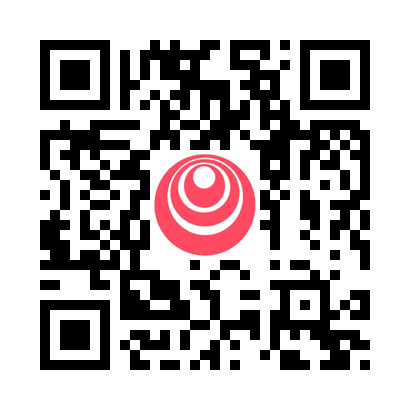

In [18]:
from IPython.display import Image, display

# Display image directly
Image('dl_qr_code.png')

In [19]:
prompt = "Can you help me create a qr code that goes to www.deeplearning.ai from the image dl_logo.jpg? Also write me a txt note with the current weather please."

response = client.chat.completions.create(
    model="openai:o4-mini",
    messages=[{"role": "user", "content": (
        prompt
    )}],
    tools=[
        get_weather_from_ip,
        get_current_time,
        write_txt_file,
        generate_qr_code
    ],
    max_turns=10
)

display_functions.pretty_print_chat_completion(response)